In [90]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage.filters import gaussian_filter1d
import copy
import ptitprince as pt
from sklearn.metrics import auc



species_color = {'Marmoset': "orange",
 'Human': "green",
 'Rhesus': "blue",
 'Chimpanzee': "red",
 'Capuchin': "brown",
 "Gorilla": "pink"}

PYTHON_PATH = "/Users/rb4174/Library/CloudStorage/OneDrive-PrincetonUniversity/Projects/brain_dev_primates/altricial_brain_vocal_learning"


adult_sizes_df = pd.read_excel("/Users/rb4174/Library/CloudStorage/OneDrive-PrincetonUniversity/Projects/brain_dev_primates/data/adult_primates_brain_volumes.xlsx",
                               sheet_name="from_ref") # "from_ref", from_my_data
adult_sizes_df = adult_sizes_df.replace("chimpanzee", "Chimpanzee")
adult_sizes_df = adult_sizes_df.replace("human", "Human")
adult_sizes_df = adult_sizes_df.replace("marmoset", "Marmoset")
adult_sizes_df = adult_sizes_df.replace("rhesus", "Rhesus")
adult_sizes_df = adult_sizes_df.replace("capuchin", "Capuchin")
adult_sizes_df = adult_sizes_df.replace("gorilla", "Gorilla")

adult_size = {}
for specie in adult_sizes_df["species"].unique():
    adult_size[specie] = np.mean(adult_sizes_df[(adult_sizes_df.species == specie)]["total_cm3"])


DIVISION_DAYS = 30.5
X_LABEL = "Months post conception"

/var/folders/ys/4vmt6skn47v69q7dptm_7p3m0000gp/T/ipykernel_53914/3851573059.py:5: DeprecationWarning: Please use `gaussian_filter1d` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter1d


In [91]:
df_fit = pd.read_pickle("{0}/data/derivatives_absolute_values.pkl".format(PYTHON_PATH)) 
df_events = pd.read_excel("{0}/data/developmental_stages_events.xlsx".format(PYTHON_PATH),index_col=False)
species_list = ["Human","Marmoset","Chimpanzee","Rhesus"]#,"Capuchin","Gorilla"]
df_fit.head()

,species,x_dydx,derivatives,derivatives_max,norm_y_distance_from_peak_at_birth,x_distance_from_peak_at_birth
0,Human,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[2.9767968612759432e-05, 0.000119071969947981...","[2.3727882073224578, 2.2845172480382416, 2.330...","[[0.05838586626080628, 0.060304926367980974, 0...","[[41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48..."
1,Marmoset,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[-2.2239987629291136e-12, -2.275957200481571e...","[0.08040404281801461, 0.0779368340649027, 0.08...","[[0.20686947003891762, 0.22034040250365514, 0....","[[23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30..."
2,Chimpanzee,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[1.746744484876217e-05, 6.9869835215286e-05, ...","[1.128083750420302, 1.2751718080320344, 1.3197...","[[0.40711007035816765, 0.41881658772849045, 0....","[[63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70..."
3,Rhesus,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[0.009742121624014999, 0.00997707681254667, 0...","[0.788644378561397, 0.7799614374531263, 0.7628...","[[0.6483139375850314, 0.6670751785355366, 0.68...","[[44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51..."


Human
Marmoset
Chimpanzee
Rhesus


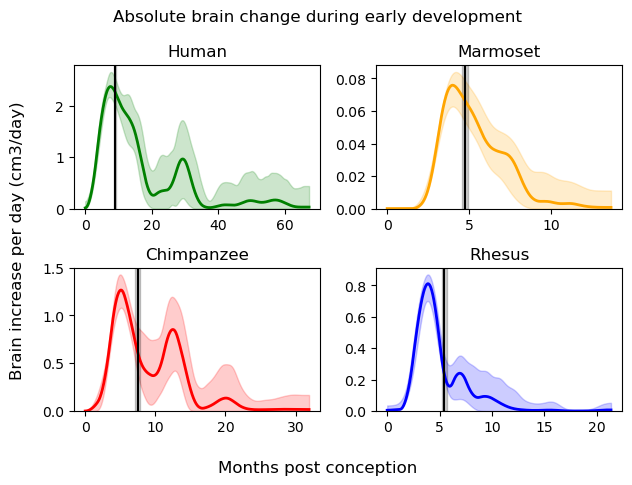

In [92]:
i = 0
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species = species_list[i]
        print(species)
        derivatives_dataset_species = df_fit[(df_fit.species == species)]
        df_event_specie = df_events[df_events.species == species]
        gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
        gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
        late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

        x = derivatives_dataset_species["x_dydx"].values[0]
        all_devs = derivatives_dataset_species["derivatives"].values[0]
        
        average_derivative = gaussian_filter1d(np.mean(np.array(all_devs), axis=0),sigma = 2)
        low_95Percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 10)
        max_95Percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 10)

        col.plot(x/DIVISION_DAYS,average_derivative, '-', color = species_color[species],linewidth = 2)
        
        col.fill_between(x/DIVISION_DAYS, low_95Percentil, max_95Percentil, color=species_color[species], alpha=0.2)

        col.axvline(x = gestation_days/DIVISION_DAYS, color = "black",linestyle = '-')
        col.axvspan(gestation_days/DIVISION_DAYS - gestation_days_sd/DIVISION_DAYS, gestation_days/DIVISION_DAYS + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color='black')
        

        col.set_title(species)
        col.set_ylim(bottom=0)
        i += 1

fig.supxlabel(X_LABEL) 
fig.supylabel('Brain increase per day (cm3/day)')
fig.suptitle("Absolute brain change during early development")
fig.tight_layout()
fig.savefig("{0}/figs/3A_derivatives_absolute.pdf".format(PYTHON_PATH),dpi = 800)
plt.show()

Human
Marmoset
Chimpanzee
Rhesus


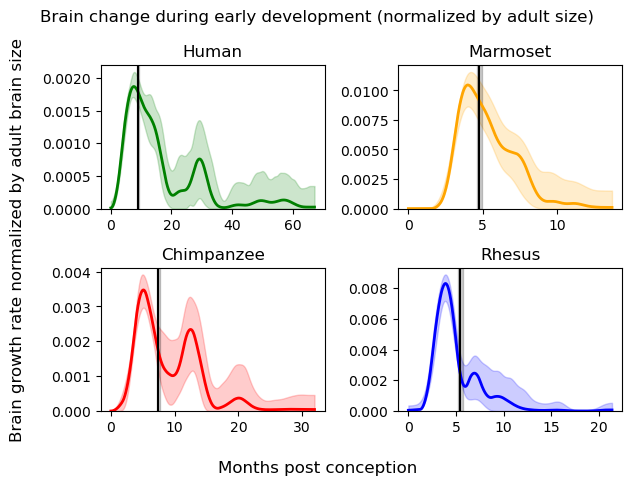

In [93]:
i = 0

derivative_fit = []
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species = species_list[i]
        print(species)
        derivatives_dataset_species = df_fit[(df_fit.species == species)]
        df_event_specie = df_events[df_events.species == species]
        gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
        gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
        late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

        x = derivatives_dataset_species["x_dydx"].values[0]
        all_devs = derivatives_dataset_species["derivatives"].values[0]
        
        average_derivative = np.mean(np.array(all_devs), axis=0)
        low_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 10)
        high_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 10)

        y = average_derivative

        y = y/adult_size[species]
        low_percentil = low_percentil/adult_size[species]
        high_percentil = high_percentil/adult_size[species]


        col.plot(x/DIVISION_DAYS,y, '-', color = species_color[species],linewidth = 2)
        col.fill_between(x/DIVISION_DAYS, low_percentil, high_percentil, color=species_color[species], alpha=0.2)

        col.axvline(x = gestation_days/DIVISION_DAYS, color = "black",linestyle = '-')
        col.axvspan(gestation_days/DIVISION_DAYS - gestation_days_sd/DIVISION_DAYS, gestation_days/DIVISION_DAYS + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color='black')
        

        xlim = late_infancy_ends
        #col.set_xlim(0,xlim)
        col.set_title(species)
        col.set_ylim(bottom=0)
        i += 1

fig.supxlabel(X_LABEL) 
fig.supylabel('Brain growth rate normalized by adult brain size')
fig.suptitle("Brain change during early development (normalized by adult size)")
fig.tight_layout()
plt.show()

Chimpanzee
Rhesus
Human
Marmoset


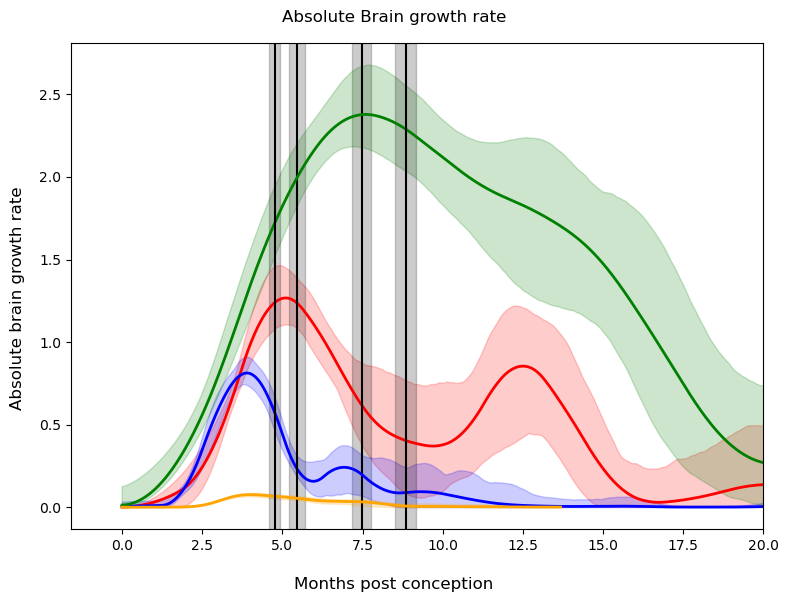

In [94]:
i = 0

derivative_fit = []
fig, ax = plt.subplots(figsize=(8, 6))

for species in ["Chimpanzee","Rhesus","Human","Marmoset"]:
    print(species)
    derivatives_dataset_species = df_fit[(df_fit.species == species)]
    df_event_specie = df_events[df_events.species == species]
    gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
    gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
    late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

    x = derivatives_dataset_species["x_dydx"].values[0]
    all_devs = derivatives_dataset_species["derivatives"].values[0]
    
    average_derivative = np.mean(np.array(all_devs), axis=0)
    low_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 1)
    high_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 1)

    y = average_derivative

    ax.plot(x/DIVISION_DAYS,y, '-', color = species_color[species],linewidth = 2)
    ax.fill_between(x/DIVISION_DAYS, low_percentil, high_percentil, color=species_color[species], alpha=0.2)

    ax.axvline(x = gestation_days/DIVISION_DAYS, color = "black",linestyle = '-')
    ax.axvspan(gestation_days/DIVISION_DAYS - gestation_days_sd/DIVISION_DAYS, gestation_days/DIVISION_DAYS + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color="black")

    ax.set_xlim(right=20)

fig.supxlabel(X_LABEL) 
fig.supylabel('Absolute brain growth rate')
fig.suptitle("Absolute Brain growth rate")
fig.savefig("{0}/figs/2B_derivatives_together_absolute.pdf".format(PYTHON_PATH),dpi = 800)
fig.tight_layout()
plt.show()

Chimpanzee
Rhesus
Human
Marmoset


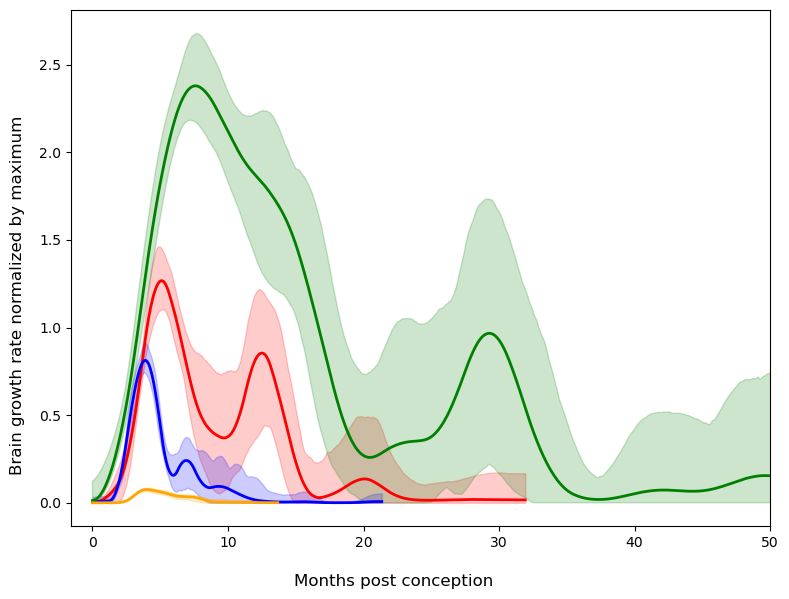

In [95]:
i = 0

derivative_fit = []
fig, ax = plt.subplots(figsize=(8, 6))

for species in ["Chimpanzee","Rhesus","Human","Marmoset"]:
    print(species)
    derivatives_dataset_species = df_fit[(df_fit.species == species)]
    df_event_specie = df_events[df_events.species == species]
    gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
    gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
    late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

    x = derivatives_dataset_species["x_dydx"].values[0]
    all_devs = derivatives_dataset_species["derivatives"].values[0]
    
    average_derivative = np.mean(np.array(all_devs), axis=0)
    low_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 1)
    high_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 1)

    y = average_derivative

    #ax.axvline(x = gestation_days/DIVISION_DAYS, color = species_color[species],linestyle = '-')
    #ax.axvspan(gestation_days/DIVISION_DAYS - gestation_days_sd/DIVISION_DAYS, gestation_days/DIVISION_DAYS + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color=species_color[species])

    ax.plot(x/DIVISION_DAYS,y, '-', color = species_color[species],linewidth = 2)
    ax.fill_between(x/DIVISION_DAYS, low_percentil, high_percentil, color=species_color[species], alpha=0.2)

    ax.set_xlim(right=50)

fig.supxlabel(X_LABEL) 
fig.supylabel('Brain growth rate normalized by maximum')
fig.tight_layout()
plt.show()

Chimpanzee
Rhesus
Human
Marmoset


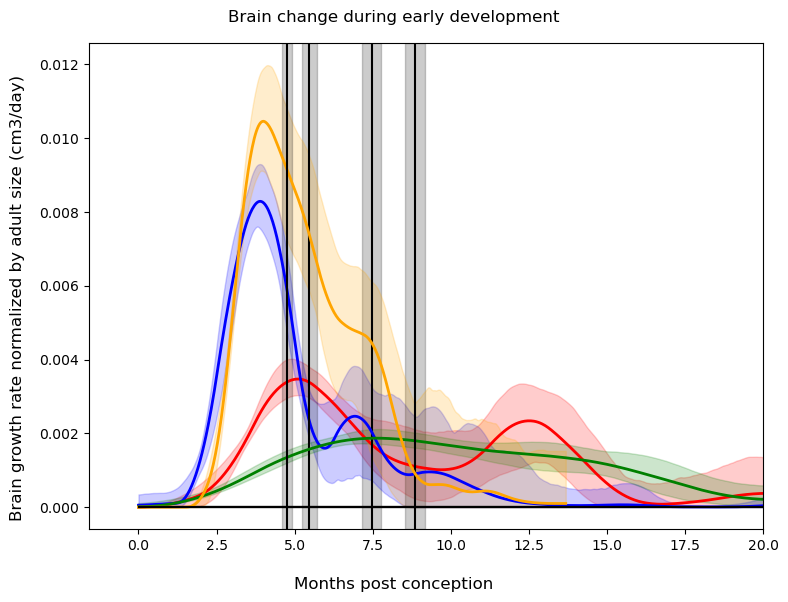

In [96]:
i = 0

derivative_fit = []
fig, ax = plt.subplots(figsize=(8, 6))

for species in ["Chimpanzee","Rhesus","Human","Marmoset"]:

    print(species)
    derivatives_dataset_species = df_fit[(df_fit.species == species)]
    df_event_specie = df_events[df_events.species == species]
    gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
    gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
    late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

    x = derivatives_dataset_species["x_dydx"].values[0]
    all_devs = derivatives_dataset_species["derivatives"].values[0]
    
    average_derivative = np.mean(np.array(all_devs), axis=0)
    low_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 1)
    high_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 1)

    y = average_derivative

    y = y/adult_size[species]
    low_percentil = low_percentil/adult_size[species]
    high_percentil = high_percentil/adult_size[species]

    ax.plot(x/DIVISION_DAYS,y, '-', color = species_color[species],linewidth = 2)
    ax.fill_between(x/DIVISION_DAYS, low_percentil, high_percentil, color=species_color[species], alpha=0.2)


    ax.hlines(0,0,20, color = "black",linestyle = '-')
    ax.axvline(x = gestation_days/DIVISION_DAYS, color = "black",linestyle = '-')
    ax.axvspan(gestation_days/DIVISION_DAYS - gestation_days_sd/DIVISION_DAYS, gestation_days/DIVISION_DAYS + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color="black")
        
    ax.set_xlim(right=20)


fig.supxlabel(X_LABEL) 
fig.suptitle("Brain change during early development")
fig.supylabel('Brain growth rate normalized by adult size (cm3/day)')
fig.tight_layout()
fig.savefig("{0}/figs/2C_derivatives_together_normalized.pdf".format(PYTHON_PATH),dpi = 800)
plt.show()

Chimpanzee
Rhesus
Human
Marmoset


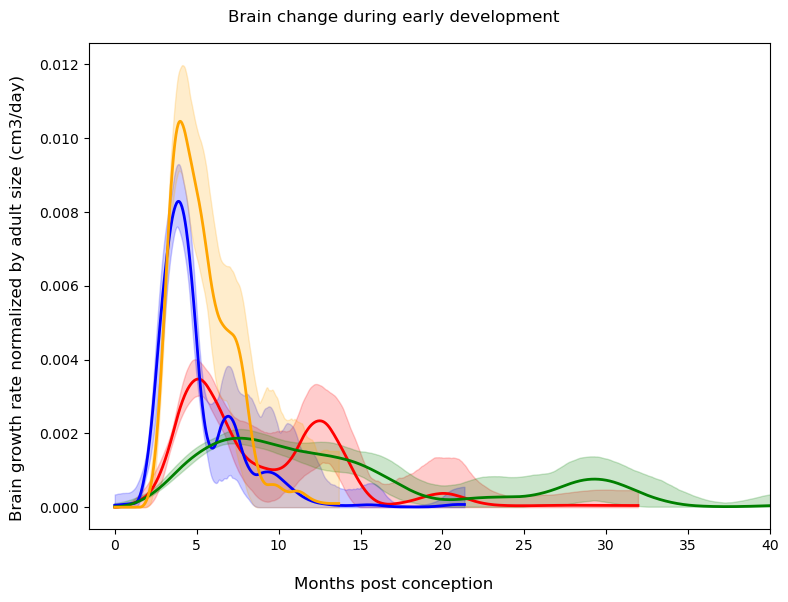

In [97]:
i = 0

derivative_fit = []
fig, ax = plt.subplots(figsize=(8, 6))

for species in ["Chimpanzee","Rhesus","Human","Marmoset"]:

    print(species)
    derivatives_dataset_species = df_fit[(df_fit.species == species)]
    df_event_specie = df_events[df_events.species == species]
    gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
    gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
    late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

    x = derivatives_dataset_species["x_dydx"].values[0]
    all_devs = derivatives_dataset_species["derivatives"].values[0]
    
    average_derivative = np.mean(np.array(all_devs), axis=0)
    low_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 1)
    high_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 1)

    y = average_derivative

    y = y/adult_size[species]
    low_percentil = low_percentil/adult_size[species]
    high_percentil = high_percentil/adult_size[species]


    #ax.axvline(x = gestation_days/DIVISION_DAYS, color = species_color[species],linestyle = '-')
    #ax.axvspan(gestation_days/DIVISION_DAYS - gestation_days_sd/DIVISION_DAYS, gestation_days/DIVISION_DAYS + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color=species_color[species])
        
    ax.plot(x/DIVISION_DAYS,y, '-', color = species_color[species],linewidth = 2)
    ax.fill_between(x/DIVISION_DAYS, low_percentil, high_percentil, color=species_color[species], alpha=0.2)

    ax.set_xlim(right=40)


fig.supxlabel(X_LABEL) 
fig.supylabel('Brain growth rate normalized by adult size (cm3/day)')
fig.suptitle("Brain change during early development")
fig.tight_layout()
plt.show()

Chimpanzee
Rhesus
Human
Marmoset


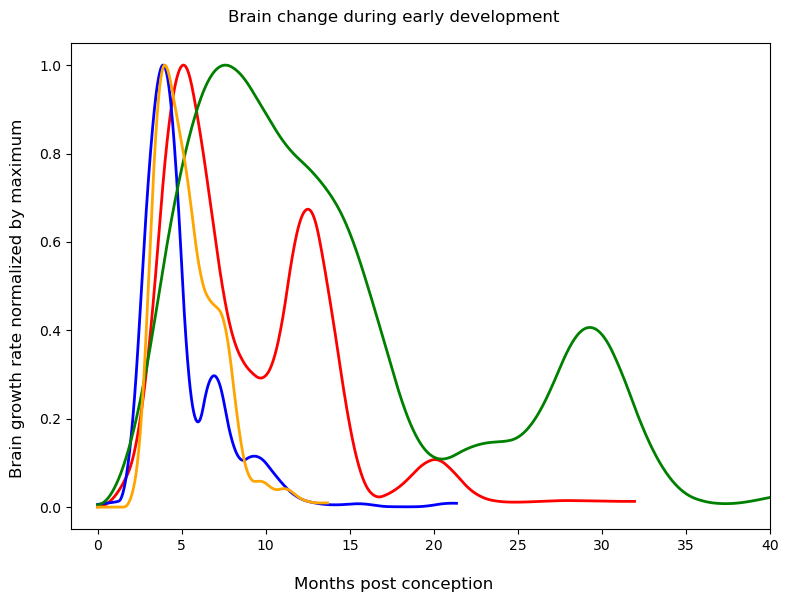

In [98]:
i = 0

derivative_fit = []
fig, ax = plt.subplots(figsize=(8, 6))

for species in ["Chimpanzee","Rhesus","Human","Marmoset"]:

    print(species)
    derivatives_dataset_species = df_fit[(df_fit.species == species)]
    df_event_specie = df_events[df_events.species == species]
    gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
    gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
    late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

    x = derivatives_dataset_species["x_dydx"].values[0]
    all_devs = derivatives_dataset_species["derivatives"].values[0]
    
    average_derivative = np.mean(np.array(all_devs), axis=0)
    low_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 1)
    high_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 1)

    y = average_derivative

    y = y/np.max(y)
    #low_percentil = low_percentil/adult_size[species]
    #high_percentil = high_percentil/adult_size[species]


    #ax.axvline(x = gestation_days/DIVISION_DAYS, color = species_color[species],linestyle = '-')
    #ax.axvspan(gestation_days/DIVISION_DAYS - gestation_days_sd/DIVISION_DAYS, gestation_days/DIVISION_DAYS + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color=species_color[species])
        
    ax.plot(x/DIVISION_DAYS,y, '-', color = species_color[species],linewidth = 2)
    #ax.fill_between(x/DIVISION_DAYS, low_percentil, high_percentil, color=species_color[species], alpha=0.2)

    ax.set_xlim(right=40)


fig.supxlabel(X_LABEL) 
fig.supylabel('Brain growth rate normalized by maximum')
fig.suptitle("Brain change during early development")
fig.tight_layout()
plt.show()

# Distance from the peak calculations

In [99]:
distances_from_peak_plot = {"species":[],
                            "close_to_peak_norm":[],
                            "distance_from_peak_norm":[],
                            "distance_from_peak_abs":[]}

for species in species_list:
    derivatives_dataset_species = df_fit[(df_fit.species == species)]
    distance_y_norm = derivatives_dataset_species["norm_y_distance_from_peak_at_birth"].values[0]
    derivatives_max = derivatives_dataset_species["derivatives_max"].values[0]


    all_distance_from_peak_norm = []
    all_distance_from_peak_abs = []
    all_close_to_peak_norm = []
    for index, peak_distance in enumerate(distance_y_norm):
        all_distance_from_peak_norm.extend(np.array(peak_distance))
        all_close_to_peak_norm.extend(1-np.array(peak_distance))
        all_distance_from_peak_abs.extend(np.array(peak_distance)*derivatives_max[index])
    
    distances_from_peak_plot["species"].extend([species]*len(all_distance_from_peak_norm))
    distances_from_peak_plot["distance_from_peak_norm"].extend(all_distance_from_peak_norm)
    distances_from_peak_plot["close_to_peak_norm"].extend(all_close_to_peak_norm)
    distances_from_peak_plot["distance_from_peak_abs"].extend(all_distance_from_peak_abs)


distances_from_peak_plot = pd.DataFrame(distances_from_peak_plot)
  
#for ploting
SPECIES = ["Human", "Marmoset","Chimpanzee", "Rhesus"]
COLORS = ["#1A936F","#FFB400","#FF5A5F", "#007A87",]
SHIFT = 0.05
POSITIONS = [0 + SHIFT, 1 + SHIFT, 2 + SHIFT, 3+ SHIFT]
# The style of the line that represents the median.
medianprops = {"linewidth": 1.5, "color": "#a9a9a9", "solid_capstyle": "butt"}
# The style of the box ... This is also used for the whiskers
boxprops = {"linewidth": 1.5, "color": "#a9a9a9"}




x_distance_from_peak_df = {"species":[],
                            "horizontal_distance_from_peak":[]}

for species in species_list:
    print(species)
    derivatives_dataset_species = df_fit[(df_fit.species == species)]
    distance_x = derivatives_dataset_species["x_distance_from_peak_at_birth"].values[0]

    all_horizontal_distance_from_peak_abs = []
    for index, peak_distance in enumerate(distance_x):
        all_horizontal_distance_from_peak_abs.extend(np.array(peak_distance))
    
    x_distance_from_peak_df["species"].extend([species]*len(all_horizontal_distance_from_peak_abs))
    x_distance_from_peak_df["horizontal_distance_from_peak"].extend(all_horizontal_distance_from_peak_abs)  

x_distance_from_peak_df = pd.DataFrame(x_distance_from_peak_df)


Human
Marmoset
Chimpanzee
Rhesus


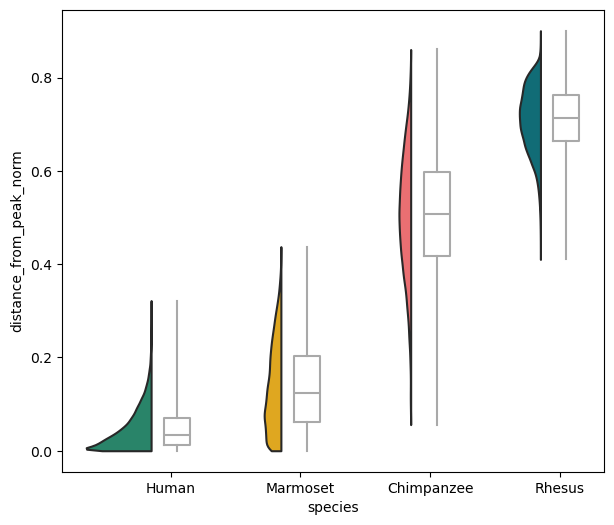

In [100]:
PLOT_VARIABLE = "distance_from_peak_norm"
fig, ax = plt.subplots(figsize=(7, 6))
pt.half_violinplot(
    y=PLOT_VARIABLE, x="species", palette=COLORS, 
    inner=None, data=distances_from_peak_plot, width=1, ax=ax,cut=0)

boxplot_data = [
    distances_from_peak_plot[distances_from_peak_plot["species"] == species][PLOT_VARIABLE].values 
    for species in SPECIES]

ax.boxplot(boxplot_data, 
    vert=True, positions=POSITIONS, manage_ticks=False, showfliers = False, showcaps = False,  
    medianprops = medianprops, whiskerprops = boxprops,boxprops = boxprops, widths=0.2,whis=[0, 100])

plt.savefig("{0}/figs/3B_clouds_peak_distance.pdf".format(PYTHON_PATH),dpi = 200)


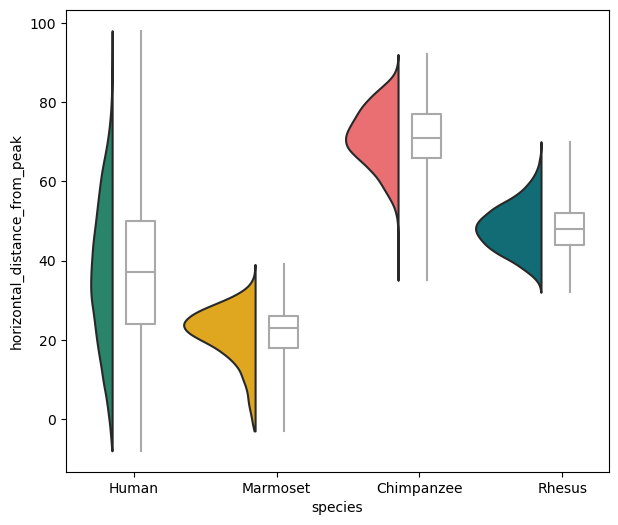

In [101]:
PLOT_VARIABLE = "horizontal_distance_from_peak"
fig, ax = plt.subplots(figsize=(7, 6))
pt.half_violinplot(
    y=PLOT_VARIABLE, x="species", palette=COLORS, 
    inner=None, data=x_distance_from_peak_df, width=1, ax=ax,cut=0)

boxplot_data = [
    x_distance_from_peak_df[x_distance_from_peak_df["species"] == species][PLOT_VARIABLE].values 
    for species in SPECIES]

ax.boxplot(boxplot_data, 
    vert=True, positions=POSITIONS, manage_ticks=False, showfliers = False, showcaps = False,  
    medianprops = medianprops, whiskerprops = boxprops,boxprops = boxprops, widths=0.2,whis=[0, 100])

plt.savefig("{0}/figs/3B_clouds_horizontal_peak_distance.pdf".format(PYTHON_PATH),dpi = 200)


## percentil bonds of the distributions

In [102]:
percentil = 0.95

for species in species_list:
    lower_percentile = (1 - percentil) / 2
    upper_percentile = 1 - lower_percentile
    data = distances_from_peak_plot[distances_from_peak_plot.species == species]["distance_from_peak_norm"]
    percentil_interval = np.percentile(data, [100 * lower_percentile, 100 * upper_percentile])

    mean = np.mean(data)
    median = np.median(data)
    std = np.std(data)


    print(species)
    print(f"Mean: {round(mean,2)}, Median: {round(median,2)}, Std: {round(std,2)}")
    print(f"95% Percentil bounds: {percentil_interval}")
    print()

Human
Mean: 0.05, Median: 0.03, Std: 0.04
95% Percentil bounds: [0.00028442 0.15656175]

Marmoset
Mean: 0.14, Median: 0.12, Std: 0.09
95% Percentil bounds: [0.00267857 0.32653693]

Chimpanzee
Mean: 0.5, Median: 0.51, Std: 0.13
95% Percentil bounds: [0.24225918 0.73899826]

Rhesus
Mean: 0.71, Median: 0.71, Std: 0.07
95% Percentil bounds: [0.56775799 0.82188423]



## ROC curve

<Axes: xlabel='close_to_peak_norm', ylabel='Count'>

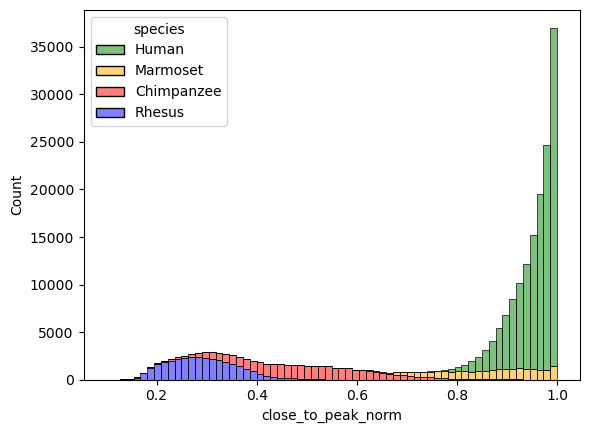

In [103]:
sns.histplot(hue="species", x="close_to_peak_norm", data=distances_from_peak_plot,multiple="stack", alpha = 0.5,
            palette=["green","orange","red","blue"],common_norm=False)

In [104]:
df_all_box = pd.DataFrame(distances_from_peak_plot)
df_all_box.head()

,species,close_to_peak_norm,distance_from_peak_norm,distance_from_peak_abs
0,Human,0.941614,0.058386,0.138537
1,Human,0.939695,0.060305,0.143091
2,Human,0.937777,0.062223,0.147642
3,Human,0.935860,0.064140,0.152191
4,Human,0.933943,0.066057,0.156738


In [105]:
#ROC calculation
def calculating_roc(altricial_species,precocial_species,confusion_matrix,pair,step=0.01):


    for threshold in np.arange(0, 1 + step, step):
        confusion_matrix["threshold"].append(threshold) #if value <= threshold --> it is altricial (True)
        confusion_matrix["pair_comparison"].append("{0}_{1}".format(pair[0],pair[1]))

        tp = len(altricial_species[altricial_species.distance_from_peak_norm <= threshold])
        confusion_matrix["actually_altricial_predicted_altricial"].append(tp)

        fp = len(precocial_species[precocial_species.distance_from_peak_norm <= threshold])
        confusion_matrix["actually_precocial_predicted_altricial"].append(fp)

        fn = len(altricial_species[altricial_species.distance_from_peak_norm > threshold])
        confusion_matrix["actually_altricial_predicted_precocial"].append(fn)

        tn = len(precocial_species[precocial_species.distance_from_peak_norm > threshold])
        confusion_matrix["actually_precocial_predicted_precocial"].append(tn)

        try:
            confusion_matrix["TPR"].append(tp/(tp + fn))
        except:
            confusion_matrix["TPR"].append(0)
        try:
            confusion_matrix["FPR"].append(fp/(tn + fp))
        except:
            confusion_matrix["FPR"].append(0)

    return confusion_matrix

confusion_matrix_ref = {"actually_altricial_predicted_altricial":[],"actually_precocial_predicted_altricial":[],
                            "actually_altricial_predicted_precocial":[],"actually_precocial_predicted_precocial":[],
                            "pair_comparison":[],"threshold":[],
                            "TPR":[], #true positive rate/recall/sensitivity or true positive/ all positive ("altricials I got right/all altricials")
                            "FPR":[], #false positive rate/ false alarm rate or false positive/ all negative ("precocials I classified as altricial/ all precocials")
                            }

list_of_pairs = [["Marmoset","Rhesus"],["Marmoset","Chimpanzee"],["Human","Rhesus"],["Human","Chimpanzee"],
                ["Human","Marmoset"],["Chimpanzee","Rhesus"]]


confusion_matrix = copy.deepcopy(confusion_matrix_ref)

for pair in list_of_pairs:
    print(pair)
    altricial_species = df_all_box[df_all_box.species == pair[0]]
    precocial_species = df_all_box[df_all_box.species == pair[1]]
    confusion_matrix = calculating_roc(altricial_species,precocial_species,confusion_matrix,pair,0.05)
    
confusion_matrix = pd.DataFrame(confusion_matrix)

['Marmoset', 'Rhesus']
['Marmoset', 'Chimpanzee']
['Human', 'Rhesus']
['Human', 'Chimpanzee']
['Human', 'Marmoset']
['Chimpanzee', 'Rhesus']


Marmoset_Rhesus
Marmoset_Chimpanzee
Human_Rhesus
Human_Chimpanzee
Human_Marmoset
Chimpanzee_Rhesus


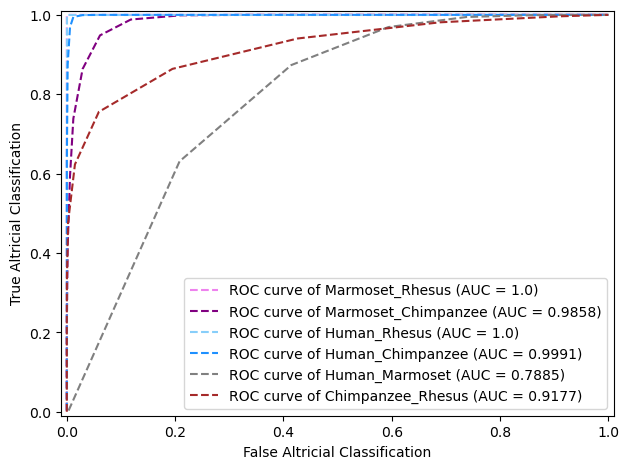

In [106]:
colors = ["violet","purple","lightskyblue","dodgerblue","grey","brown"]

auc_value = 0
for i, pair in enumerate(confusion_matrix["pair_comparison"].unique()):
    print(pair)
    conf_matrix_pair = confusion_matrix[confusion_matrix.pair_comparison == pair]
    fpr = list(conf_matrix_pair["FPR"])
    tpr = list(conf_matrix_pair["TPR"])
    auc_value = auc(fpr,tpr)
    plt.plot(fpr, tpr,"--",color = colors[i],label='ROC curve of {0} (AUC = {1})'.format(pair,np.round(auc_value,4)))

plt.xlim(-0.01,1.01)
plt.ylim(-0.01,1.01)
plt.legend()
plt.xlabel("False Altricial Classification")
plt.ylabel("True Altricial Classification")
plt.tight_layout()
plt.savefig("{0}/figs/3C_ROC.pdf".format(PYTHON_PATH),dpi = 300)


# Fig 4

Human
Marmoset
Chimpanzee
Rhesus


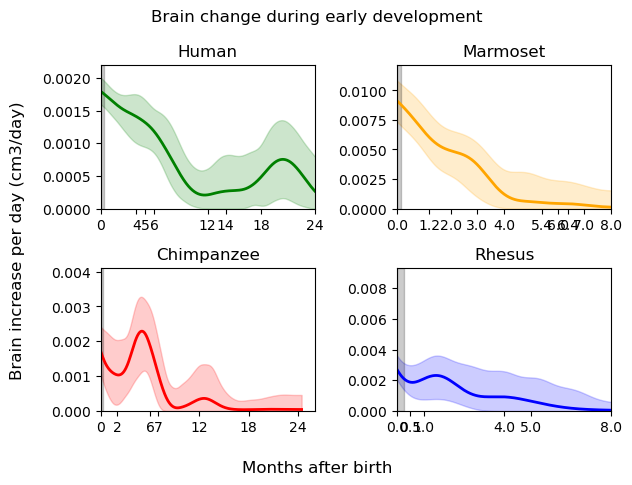

In [107]:
i = 0
derivative_fit = []
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species = species_list[i]
        print(species)
        derivatives_dataset_species = df_fit[(df_fit.species == species)]
        df_event_specie = df_events[df_events.species == species]
        gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
        gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
        late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

        x = derivatives_dataset_species["x_dydx"].values[0]
        all_devs = derivatives_dataset_species["derivatives"].values[0]
        
        average_derivative = gaussian_filter1d(np.mean(np.array(all_devs), axis=0), sigma = 10)/adult_size[species]
        low_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 10)/adult_size[species]
        high_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 10)/adult_size[species]

        y = average_derivative

        col.plot(x/DIVISION_DAYS - gestation_days/DIVISION_DAYS,y, '-', color = species_color[species],linewidth = 2)
        col.fill_between(x/DIVISION_DAYS - gestation_days/DIVISION_DAYS, low_percentil, high_percentil, color=species_color[species], alpha=0.2)

        col.axvline(x = 0 , color = "black",linestyle = '-')
        col.axvspan(0 - gestation_days_sd/DIVISION_DAYS, 0 + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color='black')
        

        col.set_title(species)
        col.set_ylim(bottom=0)
        col.set_xlim(left=0)

        # Set x-axis ticks every 6 months
        max_months = (x.max() / DIVISION_DAYS) - (gestation_days / DIVISION_DAYS)
        if species == "Human":
            ticks = np.arange(0, 24 + 1, 6).tolist()
            col.set_xlim(right=24)
            if 5 not in ticks:
                ticks.append(4) #synaptic peak
                ticks.append(5)  # Add month 5 if not already included
                ticks.append(14)  # which is remarkably in line with the peaking age of human cortical thickness at around 14 mo of age (29) F. Wang et al., Developmental topography of cortical thickness during infancy. Proc. Natl. Acad. Sci. U.S.A. 116, 15855–15860 (2019).
            ticks = sorted(ticks)  # Ensure the ticks are sorted
            col.set_xticks(ticks)
        elif species == "Marmoset":
            ticks = np.arange(0, max_months + 1, 2).tolist()
            ticks.append(3)
            ticks.append(7)
            ticks.append(6.4) #auditory peak
            ticks.append(5.4) 
            ticks.append(1.2) 
            ticks = sorted(ticks)  # Ensure the ticks are sorted
            col.set_xticks(ticks)
            col.set_xlim(right=8)
        elif species == "Rhesus":
            ticks = np.arange(0, 8 + 1, 4).tolist()
            ticks.append(5) #peak of cortical tickness https://www.pnas.org/doi/10.1073/pnas.2303313120#sec-3
            ticks.append(0.5) #peak of cortical tickness https://www.pnas.org/doi/10.1073/pnas.2303313120#sec-3
            ticks.append(1) #peak of cortical tickness https://www.pnas.org/doi/10.1073/pnas.2303313120#sec-3
            ticks = sorted(ticks)  # Ensure the ticks are sorted
            col.set_xticks(ticks)
            col.set_xlim(right=8)
        elif species == "Chimpanzee":
            ticks = np.arange(0, max_months + 1, 6).tolist()
            ticks.append(2) #https://onlinelibrary-wiley-com.ezproxy.princeton.edu/doi/10.1111/j.1467-7687.2011.01069.x
            ticks.append(7) #https://onlinelibrary-wiley-com.ezproxy.princeton.edu/doi/10.1111/j.1467-7687.2011.01069.x
            ticks = sorted(ticks)  # Ensure the ticks are sorted
            col.set_xticks(ticks)
        #The grunting rates in this context increase over the following months with a peak around the seventh month, coinciding with Goodall’s (1986) observation of the onset of greeting grunts.
        #Bründl et al., 2021
        i += 1

fig.supxlabel("Months after birth") 
fig.supylabel('Brain increase per day (cm3/day)')
fig.suptitle("Brain change during early development")
fig.tight_layout()
fig.savefig("{0}/figs/4_derivatives_after_birth_normAdultSize.pdf".format(PYTHON_PATH),dpi = 800)
plt.show()

Human
Marmoset
Chimpanzee
Rhesus


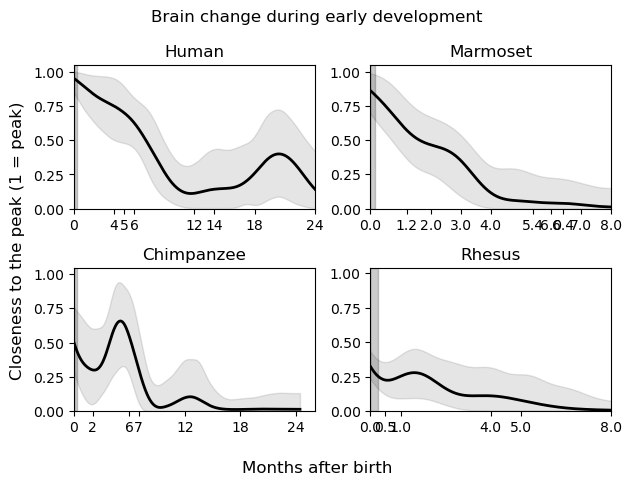

In [110]:
i = 0
derivative_fit = []
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species = species_list[i]
        print(species)
        derivatives_dataset_species = df_fit[(df_fit.species == species)]
        df_event_specie = df_events[df_events.species == species]
        gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
        gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
        late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

        x = derivatives_dataset_species["x_dydx"].values[0]
        all_devs = derivatives_dataset_species["derivatives"].values[0]

        all_devs_distance_from_peak = []
        for each in all_devs:
            peak = np.max(each)
            all_devs_distance_from_peak.append(1 - (peak - each)/peak)
        
        average_derivative = gaussian_filter1d(np.mean(np.array(all_devs_distance_from_peak), axis=0), sigma = 10)
        low_percentil = gaussian_filter1d(np.percentile(np.array(all_devs_distance_from_peak),q = 2.5, axis=0), sigma = 10)
        high_percentil = gaussian_filter1d(np.percentile(np.array(all_devs_distance_from_peak),q = 97.5, axis=0), sigma = 10)

        y = average_derivative

        col.plot(x/DIVISION_DAYS - gestation_days/DIVISION_DAYS,y, '-', color = "black",linewidth = 2)
        col.fill_between(x/DIVISION_DAYS - gestation_days/DIVISION_DAYS, low_percentil, high_percentil, color="black", alpha=0.1)

        col.axvline(x = 0 , color = "black",linestyle = '-')
        col.axvspan(0, 0 + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color='black')
        

        col.set_title(species)
        col.set_ylim(bottom=0)
        col.set_xlim(left=0)

        # Set x-axis ticks every 6 months
        max_months = (x.max() / DIVISION_DAYS) - (gestation_days / DIVISION_DAYS)
        if species == "Human":
            ticks = np.arange(0, 24 + 1, 6).tolist()
            col.set_xlim(right=24)
            if 5 not in ticks:
                ticks.append(4) #synaptic peak
                ticks.append(5)  # Add month 5 if not already included
                ticks.append(14)  # which is remarkably in line with the peaking age of human cortical thickness at around 14 mo of age (29) F. Wang et al., Developmental topography of cortical thickness during infancy. Proc. Natl. Acad. Sci. U.S.A. 116, 15855–15860 (2019).
            ticks = sorted(ticks)  # Ensure the ticks are sorted
            col.set_xticks(ticks)
        elif species == "Marmoset":
            ticks = np.arange(0, max_months + 1, 2).tolist()
            ticks.append(3)
            ticks.append(7)
            ticks.append(6.4) #auditory peak
            ticks.append(5.4) 
            ticks.append(1.2) 
            ticks = sorted(ticks)  # Ensure the ticks are sorted
            col.set_xticks(ticks)
            col.set_xlim(right=8)
        elif species == "Rhesus":
            ticks = np.arange(0, 8 + 1, 4).tolist()
            ticks.append(5) #peak of cortical tickness https://www.pnas.org/doi/10.1073/pnas.2303313120#sec-3
            ticks.append(0.5) #peak of cortical tickness https://www.pnas.org/doi/10.1073/pnas.2303313120#sec-3
            ticks.append(1) #peak of cortical tickness https://www.pnas.org/doi/10.1073/pnas.2303313120#sec-3
            ticks = sorted(ticks)  # Ensure the ticks are sorted
            col.set_xticks(ticks)
            col.set_xlim(right=8)
        elif species == "Chimpanzee":
            ticks = np.arange(0, max_months + 1, 6).tolist()
            ticks.append(2) #https://onlinelibrary-wiley-com.ezproxy.princeton.edu/doi/10.1111/j.1467-7687.2011.01069.x
            ticks.append(7) #https://onlinelibrary-wiley-com.ezproxy.princeton.edu/doi/10.1111/j.1467-7687.2011.01069.x
            ticks = sorted(ticks)  # Ensure the ticks are sorted
            col.set_xticks(ticks)
        #The grunting rates in this context increase over the following months with a peak around the seventh month, coinciding with Goodall’s (1986) observation of the onset of greeting grunts.
        #Bründl et al., 2021
        i += 1

fig.supxlabel("Months after birth") 
fig.supylabel('Closeness to the peak (1 = peak)')
fig.suptitle("Brain change during early development")
fig.tight_layout()
fig.savefig("{0}/figs/4_derivatives_after_birth_normPeakDistance.pdf".format(PYTHON_PATH),dpi = 800)
plt.show()